<a href="https://colab.research.google.com/github/BadhonPain/AI_ML/blob/ML/Titanic_EDA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
import pandas as pd

In [84]:
ds_url =" https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(ds_url)

# **Task 1: Data Loading and Initial Inspection**

In [85]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [87]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [88]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# **Task 2: Handling Missing Values**

In [89]:
df["Cabin"].isnull().sum() / len(df["Cabin"])

np.float64(0.7710437710437711)

In [90]:
# From above cell, we can see that almost 77 % passenger's cabin info is not available and it is so normal because every passenger can't have cabin.
# As cabin was only available for  1st class passenger so the Cabin info is always NaN for 2nd and 3rd class passenger. So this column can be dropped.

In [91]:
df["Embarked"].mode()

,Embarked
0,S


In [92]:
df["Embarked"].fillna(df["Embarked"].mode(), inplace=True)

/tmp/ipykernel_3726/514694571.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode(), inplace=True)


In [93]:
df["Embarked"].isnull().sum()

np.int64(2)

In [94]:
df["Age"].fillna(df["Age"].median(), inplace= True)

/tmp/ipykernel_3726/2988327869.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace= True)


In [95]:
df["Age"].isnull().sum()

np.int64(0)

# **Task 3: Univariate Analysis**

In [96]:
len(df[df["Survived"]==1])/len(df["Survived"])  # survival rate

0.3838383838383838

In [97]:
import seaborn as sb
import matplotlib.pyplot as plt

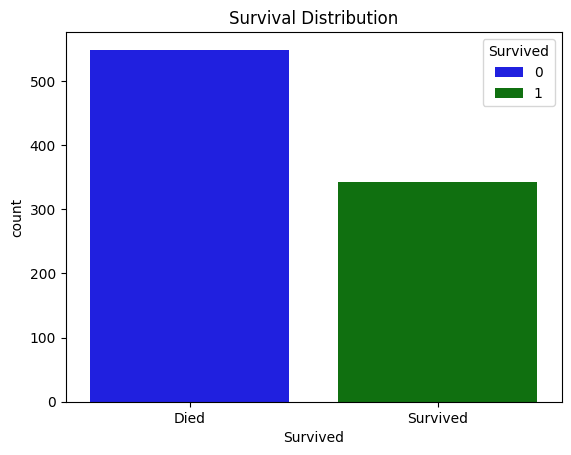

In [98]:
sb.countplot(x='Survived',hue ='Survived', data=df, palette=["blue", "green"])
plt.xticks([0,1],['Died', 'Survived'])
plt.title("Survival Distribution")
plt.show()

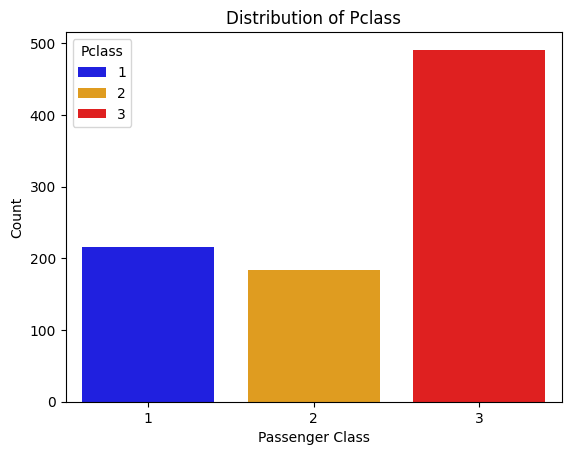

In [99]:
sb.countplot(x='Pclass', hue ='Pclass', data = df, palette=["blue","orange","red"])
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.title("Distribution of Pclass")

plt.show()

In [100]:
# From the Count Plot above, it can be said that 3rd class has more Passengers

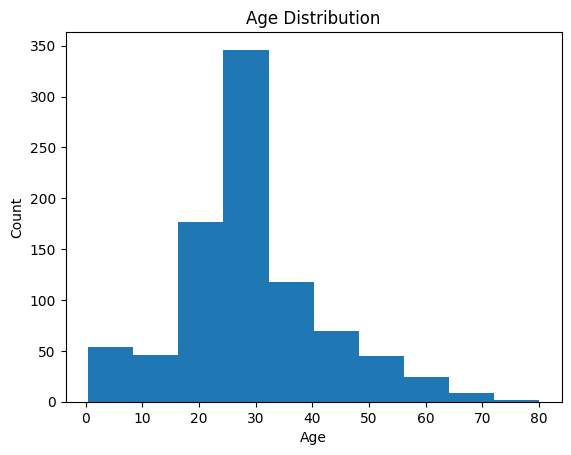

In [101]:
plt.hist(df["Age"],bins=10)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")

plt.show()

# Task 4: Bivariate and Multivariate Analysis

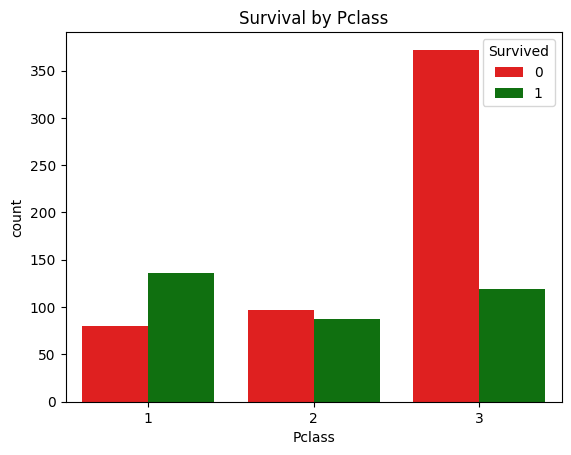

In [102]:
sb.countplot(x='Pclass',hue='Survived',data= df,palette=["red","green"])
plt.title("Survival by Pclass")

plt.show()

In [103]:
# Yes, there is a clear corelation of survival rate with ticket class. By Plotting Survival rate with Pclass, it is clear that 3rd class peoples have less chance to survive.

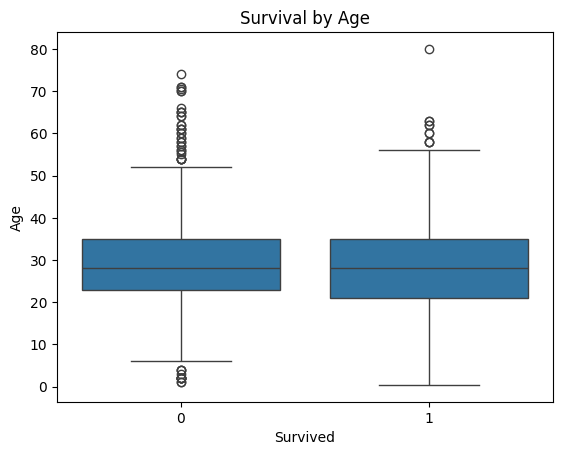

In [104]:
sb.boxplot(x="Survived",y="Age",data= df)
plt.title("Survival by Age")

plt.show()

In [105]:
survived_med = df[df["Survived"]==1]["Age"].median()
died_med = df[df["Survived"]==0]["Age"].median()
print("Median Age of Survived Passenger:",survived_med)
print("Median Age of Died Passenger:",died_med)

Median Age of Survived Passenger: 28.0
Median Age of Died Passenger: 28.0


In [106]:
# From Plot, it is clear that the childrens below 10 have higher chance of survival while not so many elders have survived.

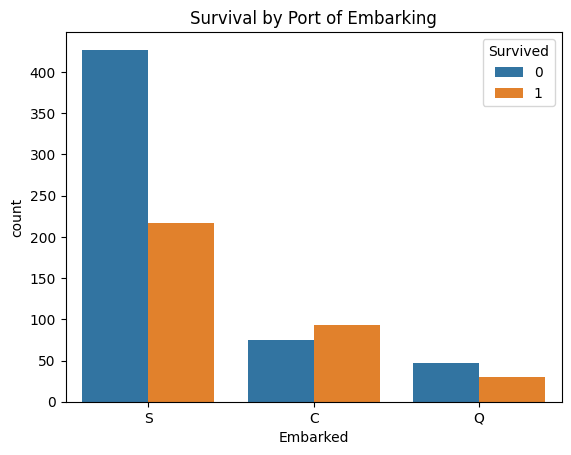

In [107]:
sb.countplot(x='Embarked', hue='Survived',data= df)
plt.title("Survival by Port of Embarking")

plt.show()

In [108]:
df[["Embarked","Survived"]].groupby("Embarked").mean().sort_values(by="Survived",ascending=False)

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


# **Task 5: Conclusion and Insights**



1. Female and Children (especially less than equal 10 or around it) have higher chances of survival.
2. 1st and 2nd class people were got prioritized as a result they have higher chances of survival . Consequently, 3rd class passengers have low rate of survival.
3. Male passengers have lower survival chances than Female.
4. From above analysis, we have already seen than the passengers who embarked from Cherbourg has higher survival chance because in this port the average fare is much higher than other ports.


